In [1]:
import os
import zipfile

In [2]:
from src.data_prep import load_data
from src.train import train_primary_model, train_secondary_model, add_safe_prediction
from src.evaluate import plot_model, plot_predictions

In [3]:
!kaggle datasets download -d robikscube/hourly-energy-consumption

Dataset URL: https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption
License(s): CC0-1.0
hourly-energy-consumption.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
with zipfile.ZipFile("hourly-energy-consumption.zip", 'r') as zip_reference:
    zip_reference.extractall("data")

In [5]:
csv_path = "data/PJME_hourly.csv"
df = load_data(csv_path)

In [6]:
df.head

<bound method NDFrame.head of                   Datetime  PJME_MW  hour  dayofweek  month  lag_24h  \
168    2002-12-24 01:00:00  27213.0     1          1     12  27669.0   
169    2002-12-24 02:00:00  25643.0     2          1     12  26162.0   
170    2002-12-24 03:00:00  24907.0     3          1     12  25483.0   
171    2002-12-24 04:00:00  24721.0     4          1     12  25045.0   
172    2002-12-24 05:00:00  25144.0     5          1     12  25030.0   
...                    ...      ...   ...        ...    ...      ...   
145361 2018-01-01 20:00:00  44284.0    20          0      1  45787.0   
145362 2018-01-01 21:00:00  43751.0    21          0      1  45209.0   
145363 2018-01-01 22:00:00  42402.0    22          0      1  43663.0   
145364 2018-01-01 23:00:00  40164.0    23          0      1  41581.0   
145365 2018-01-02 00:00:00  38608.0     0          1      1  39451.0   

        lag_1week  rolling_3h_max  rolling_24h_max  
168       26498.0         31932.0          32828.0  

In [7]:
df = df.sort_values('Datetime')

y = df['PJME_MW']
x = df.drop(columns=['Datetime', 'PJME_MW'])

In [8]:
validation_set_split_index = int(len(df) * 0.70)
testing_set_split_index = int(len(df) * 0.85)

x_training_set = x.iloc[:validation_set_split_index]
y_training_set = y.iloc[:validation_set_split_index]

x_validation_set = x.iloc[validation_set_split_index:testing_set_split_index]
y_validation_set = y.iloc[validation_set_split_index:testing_set_split_index]

x_testing_set = x.iloc[testing_set_split_index:]
y_testing_set = y.iloc[testing_set_split_index:]

In [9]:
best_parameters = train_primary_model(x_training_set, y_training_set)

final_model = train_secondary_model(x_training_set, y_training_set, x_validation_set, y_validation_set, best_parameters)

safe_predictions, base_predictions = add_safe_prediction(
    model=final_model, 
    x_validation_set=x_validation_set, 
    y_validation_set=y_validation_set, 
    x_testing_set=x_testing_set, 
    std_multiplier=1.5
)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[0]	validation_0-rmse:5665.55989
[99]	validation_0-rmse:926.07644
Validation Residual Std Dev: 925.51 MW


Mean Absolute Error: 688.7371579789371 MW


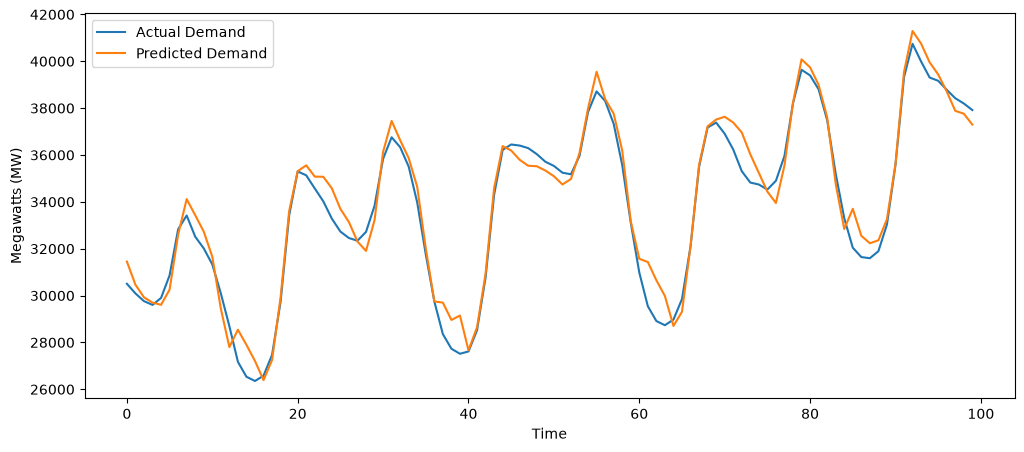

In [10]:
plot_model(final_model, x_testing_set, y_testing_set)

Base Model Mean Absolute Error: 688.74 MW
Safe Model (Buffered) Mean Absolute Error: 1523.03 MW


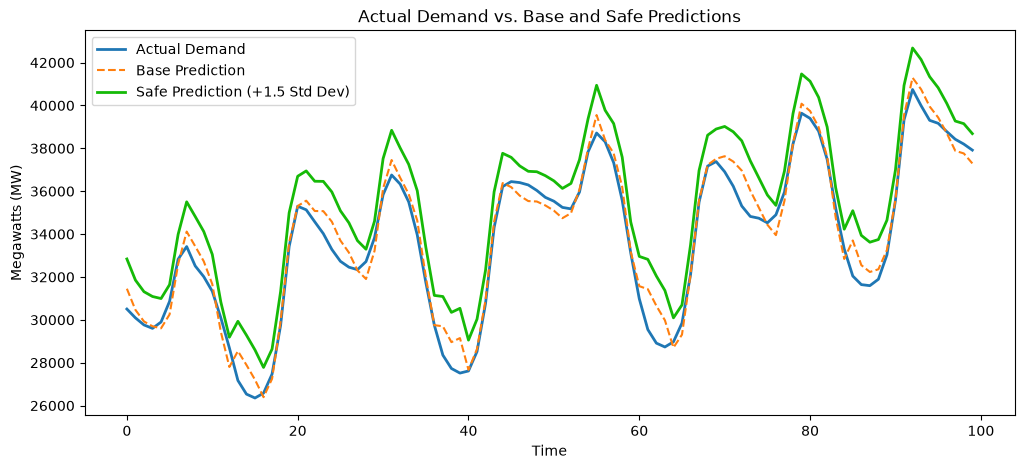

In [11]:
plot_predictions(y_testing_set, base_predictions, safe_predictions)